# Лабораторная работа по просодике

In [25]:
pip install catboost

In [26]:
import xml.etree.ElementTree as ET
import pprint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
from scipy.stats import randint

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score, mean_absolute_percentage_error, classification_report

from catboost import CatBoostRegressor

## Парсинг XML-файла

In [27]:
def parse_word(word_el):
    word_dict = {}
    word_dict['original'] = word_el.attrib.get('original', '')

    if 'nucleus' in word_el.attrib:
        word_dict['nucleus'] = int(word_el.attrib['nucleus'])

    # letters
    letters = []
    for letter in word_el.findall('letter'):
        letters.append({
            'char': letter.attrib.get('char', ''),
            'flag': int(letter.attrib.get('flag', 0)),
            'allophone': None
        })
    word_dict['letters'] = letters

    # allophones
    allophones = [a.attrib['ph'] for a in word_el.findall('allophone')]
    word_dict['allophones'] = allophones

    # dictitem
    dictitem_el = word_el.find('dictitem')
    if dictitem_el is not None:
        dictitem = {k: int(v) if v.isdigit() else v for k, v in dictitem_el.attrib.items()}
        word_dict['dictitem'] = dictitem

    return word_dict


def parse_sentence(sentence_el):
    syntagmas = []
    buffer_words = []
    punkt_end = None
    intonation = None
    pause = None

    elements = list(sentence_el)
    for elem in elements:
        if elem.tag == 'word':
            buffer_words.append(parse_word(elem))

        elif elem.tag == 'content' and 'PunktEnd' in elem.attrib:
            # сохраняем пунктуацию, но не завершаем синтагму
            punkt_end = int(elem.attrib['PunktEnd'])

        elif elem.tag == 'intonation':
            intonation = int(elem.attrib.get('type', 0))

        elif elem.tag == 'pause':
            pause = {
                'type': elem.attrib.get('type'),
                'time': int(elem.attrib.get('time', 0))
            }

            # конец синтагмы: собираем всё вместе
            syntagmas.append({
                'words': buffer_words,
                'punkt_end': punkt_end,
                'intonation': intonation,
                'pause': pause
            })

            # сброс для новой синтагмы
            buffer_words = []
            punkt_end = None
            intonation = None
            pause = None

    return syntagmas


def parse_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    all_sentences = []
    for sentence_el in root.findall('.//sentence'):
        syntagmas = parse_sentence(sentence_el)
        all_sentences.append(syntagmas)
    return all_sentences


In [28]:
path = r'/content/bunin_i_a-text_2622.Result.xml'

In [29]:
try:
    data = parse_xml(path)
except ET.ParseError as e:
    print(f"XML Parse Error: {e}")
    print("Please check the XML file for structural issues.")
    data = None # Set data to None or handle the error as appropriate for your workflow

In [30]:
# пример разметки
pprint.pprint(data[0])

[{'intonation': 11,
  'pause': {'time': 1376, 'type': 'x-long'},
  'punkt_end': 1,
  'words': [{'allophones': ["t'", 'o0', 'm', 'n', 'y4', 'j', 'i4'],
             'dictitem': {'form': 39,
                          'genesys': 0,
                          'stress_dict': 1,
                          'subpart_of_speech': 3,
                          'yo_place1': 1},
             'letters': [{'allophone': None, 'char': 'т', 'flag': 16},
                         {'allophone': None, 'char': 'ё', 'flag': 25},
                         {'allophone': None, 'char': 'м', 'flag': 16},
                         {'allophone': None, 'char': 'н', 'flag': 16},
                         {'allophone': None, 'char': 'ы', 'flag': 24},
                         {'allophone': None, 'char': 'е', 'flag': 24}],
             'original': 'ТЕМНЫЕ'},
            {'allophones': ['a1', "l'", 'e0', 'i4'],
             'dictitem': {'form': 9,
                          'genesys': 5,
                          'stress_dict': 

## Получение признаков

In [33]:
def get_features(data):
    vowels = set('аеёиоуыэюяАЕЁИОУЫЭЮЯ')  # набор гласных (для русского языка)

    def count_vowels(word):
        """Подсчет количества гласных в слове"""
        return sum(1 for ch in word if ch in vowels)

    rows = []
    synt_num = 0

    for sent in data:
        total_sent_len = sum(
            len([w for w in synt['words'] if w['dictitem'].get('stress_dict')])
            for synt in sent
        ) # считаем общее число фонетических слов в предложении
        sent_len = 0 # сколько фонетических слов мы уже прошли в предложении

        for j, synt in enumerate(sent):
            # Интонацию, паузы и пунктуацию получаем для каждой синтагмы
            synt_num += 1
            intonation = synt['intonation']

            if synt['pause'] is not None:
                synt_pause_len = synt['pause']['time']
                synt_pause_type = synt['pause']['type']
            else:
                synt_pause_len = None
                synt_pause_type = None

            punctuation = synt['punkt_end']

            synt_words = [w['original'] for w in synt['words'] if w['original'] != '']
            synt_len = len([w for w in synt['words'] if w['dictitem'].get('stress_dict')])
            count_phon_words = 0

            for i, word in enumerate(synt['words']):
                if word['dictitem'].get('stress_dict'):
                    count_phon_words += 1
                    words_before = count_phon_words - 1
                    words_after = synt_len - count_phon_words
                    word_index = count_phon_words

                    sent_words_before = sent_len + words_before
                    sent_words_after = total_sent_len - (sent_words_before + 1)

                    if words_after != 0: # Длительность паузы будем указывать только для последнего слова в синтагме
                        pause_len = 0
                        pause_type = 0
                    else:
                        pause_len = synt_pause_len
                        pause_type = synt_pause_type
                else: # Для слов, на которых нет ударения, будем указываь информацию такую же, как для слова за ним
                    words_before = count_phon_words
                    words_after = synt_len - (count_phon_words + 1)
                    word_index = count_phon_words + 1
                    pause_len = 0
                    pause_type = 0
                    sent_words_before = sent_len + words_before
                    sent_words_after = total_sent_len - (sent_words_before + 1)

                w = word['original']
                if w != '':
                    word_length = len(w)
                    part_of_speech = word['dictitem']['subpart_of_speech']
                    word_form = word['dictitem']['form']
                    word_genesys = word['dictitem']['genesys']
                    word_semantics1 = word['dictitem'].get('semantics1')
                    word_semantics2 = word['dictitem'].get('semantics2')

                    if i >= synt_len - 1:
                        next_word = None
                    elif i < synt_len - 2 and synt['words'][i + 1]['original'] == '':
                        next_word = synt['words'][i + 2]['original'] if i < synt_len - 1 else None
                    else:
                        next_word = synt['words'][i + 1]['original'] if i < synt_len - 1 else None

                    previous_word = synt['words'][i - 1]['original'] if i > 0 else None
                    capital_letter = 1 if w[0].isupper() else 0
                    nucleus = word.get('nucleus', 0)
                else:
                    word_length = len(synt['words'][i - 1]['original'])
                    part_of_speech = word['dictitem']['subpart_of_speech']
                    word_form = word['dictitem']['form']
                    word_genesys = word['dictitem']['genesys']
                    word_semantics1 = word['dictitem'].get('semantics1')
                    word_semantics2 = word['dictitem'].get('semantics2')

                    previous_word = synt['words'][i - 2]['original'] if i > 0 else None
                    next_word = synt['words'][i + 1]['original'] if i < synt_len - 1 else None
                    capital_letter = 0
                    nucleus = word.get('nucleus', 0)

                # --- Новое: подсчёт гласных ---
                vowels_in_word = count_vowels(w)

                # гласные во всех словах ДО текущего в синтагме
                vowels_before = sum(count_vowels(sw) for sw in synt_words[:i])
                # гласные во всех словах ПОСЛЕ текущего в синтагме
                vowels_after = sum(count_vowels(sw) for sw in synt_words[i + 1:])

                # добавляем в rows
                rows.append({
                    'word': w,
                    'synt_num': synt_num,
                    'word_length': word_length,
                    'part_of_speech': part_of_speech,
                    'word_form': word_form,
                    'word_genesys': word_genesys,
                    'word_semantics1': word_semantics1,
                    'word_semantics2': word_semantics2,
                    'word_index': word_index,
                    'words_before': words_before,
                    'words_after': words_after,
                    'sent_words_before': sent_words_before,
                    'sent_words_after': sent_words_after,
                    'vowels_in_word': vowels_in_word,
                    'vowels_before': vowels_before,
                    'vowels_after': vowels_after,
                    'previous_word': previous_word,
                    'next_word': next_word,
                    'capital_letter': capital_letter,
                    'nucleus': nucleus,
                    'intonation': intonation,
                    'pause_len': pause_len,
                    'pause_type': pause_type,
                    'punctuation': punctuation
                })

            sent_len += synt_len
    return rows


In [34]:
df = pd.DataFrame(get_features(data))
df.head()

,word,synt_num,word_length,part_of_speech,word_form,word_genesys,word_semantics1,word_semantics2,word_index,words_before,...,vowels_before,vowels_after,previous_word,next_word,capital_letter,nucleus,intonation,pause_len,pause_type,punctuation
0,ТЕМНЫЕ,1,6,3,39,0,NaN,NaN,1,0,...,0,3,None,АЛЛЕИ,1,0,11.0,0,0,1.0
1,АЛЛЕИ,1,5,2,9,5,NaN,NaN,2,1,...,3,0,ТЕМНЫЕ,None,1,2,11.0,1376,x-long,1.0
2,В,2,1,9,0,0,NaN,100.0,1,0,...,0,11,None,холодное,1,0,110.0,0,0,2.0
3,холодное,2,8,3,36,0,NaN,NaN,1,0,...,0,7,В,осеннее,0,0,110.0,0,0,2.0
4,осеннее,2,7,3,36,0,NaN,NaN,2,1,...,4,3,холодное,None,0,0,110.0,0,0,2.0


In [35]:
# Проверка на наличие пропусков
nan_cols = df.isna().any()
nan_cols

,0
word,False
synt_num,False
word_length,False
part_of_speech,False
word_form,False
word_genesys,False
word_semantics1,True
word_semantics2,True
word_index,False
words_before,False


In [36]:
print(df['intonation'].isnull().sum()) #Вышло всего три значения - скорее всего, ошибка разметки, можно убрать
df = df.dropna(subset=['intonation'])

3


In [37]:
print(df['nucleus'].isnull().sum())

0


In [38]:
  # Word Semantics и Punctuation заполнить нулями
df['word_semantics1'] = df['word_semantics1'].fillna(0)
df['word_semantics2'] = df['word_semantics2'].fillna(0)
df['pause_len'] = df['pause_len'].fillna(0)
df['punctuation'] = df['punctuation'].fillna(0)

### Статистика по данным

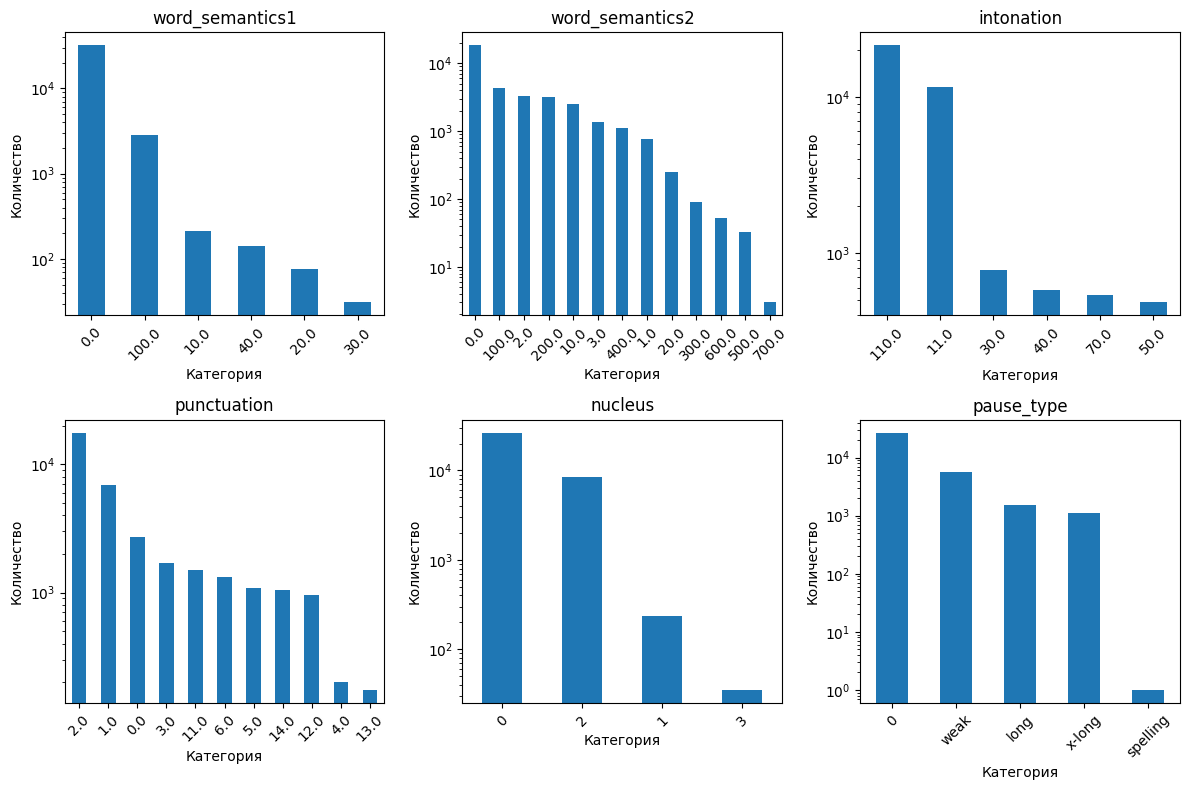

In [39]:
cols = ['word_semantics1', 'word_semantics2', 'intonation', 'punctuation', 'nucleus', 'pause_type']

n = len(cols)
rows = 2   # можно менять количество строк
cols_num = (n + rows - 1) // rows  # чтобы распределить графики равномерно

fig, axes = plt.subplots(rows, cols_num, figsize=(4*cols_num, 4*rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Категория")
    axes[i].set_ylabel("Количество")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_yscale("log")

# скрыть пустые оси, если они будут
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


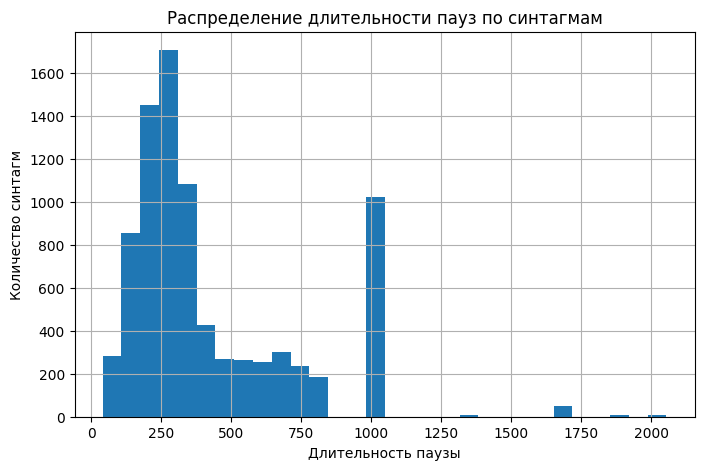

In [40]:
pause_by_synt = df[df['pause_len'] != 0]['pause_len']

plt.figure(figsize=(8, 5))
pause_by_synt.hist(bins=30)
plt.title("Распределение длительности пауз по синтагмам")
plt.xlabel("Длительность паузы")

plt.ylabel("Количество синтагм")
# логарифмическая ось
plt.show()

In [41]:
df.describe()

,synt_num,word_length,part_of_speech,word_form,word_genesys,word_semantics1,word_semantics2,word_index,words_before,words_after,sent_words_before,sent_words_after,vowels_in_word,vowels_before,vowels_after,capital_letter,nucleus,intonation,pause_len,punctuation
count,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000,35284.000000
mean,4248.520151,5.421608,5.919199,17.165259,1.325927,8.278256,45.888023,2.334543,1.334543,1.312181,8.927077,9.017657,2.088227,4.292966,4.842762,0.069096,0.491498,73.314108,101.674442,3.010005
std,2431.219225,3.184633,3.622395,24.593593,2.269189,27.182035,93.403733,1.394324,1.394324,1.448571,11.047959,11.164369,1.221128,4.383161,4.590012,0.253622,0.858898,46.378739,234.615473,3.377300
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000
25%,2162.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,11.000000,0.000000,1.000000
50%,4255.500000,5.000000,6.000000,2.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,5.000000,5.000000,2.000000,3.000000,4.000000,0.000000,0.000000,110.000000,0.000000,2.000000
75%,6332.250000,7.000000,9.000000,28.000000,2.000000,0.000000,20.000000,3.000000,2.000000,2.000000,12.000000,12.000000,3.000000,7.000000,8.000000,0.000000,0.000000,110.000000,0.000000,2.000000
max,8502.000000,25.000000,12.000000,73.000000,8.000000,100.000000,700.000000,10.000000,9.000000,9.000000,126.000000,126.000000,9.000000,34.000000,30.000000,1.000000,3.000000,110.000000,2054.000000,14.000000


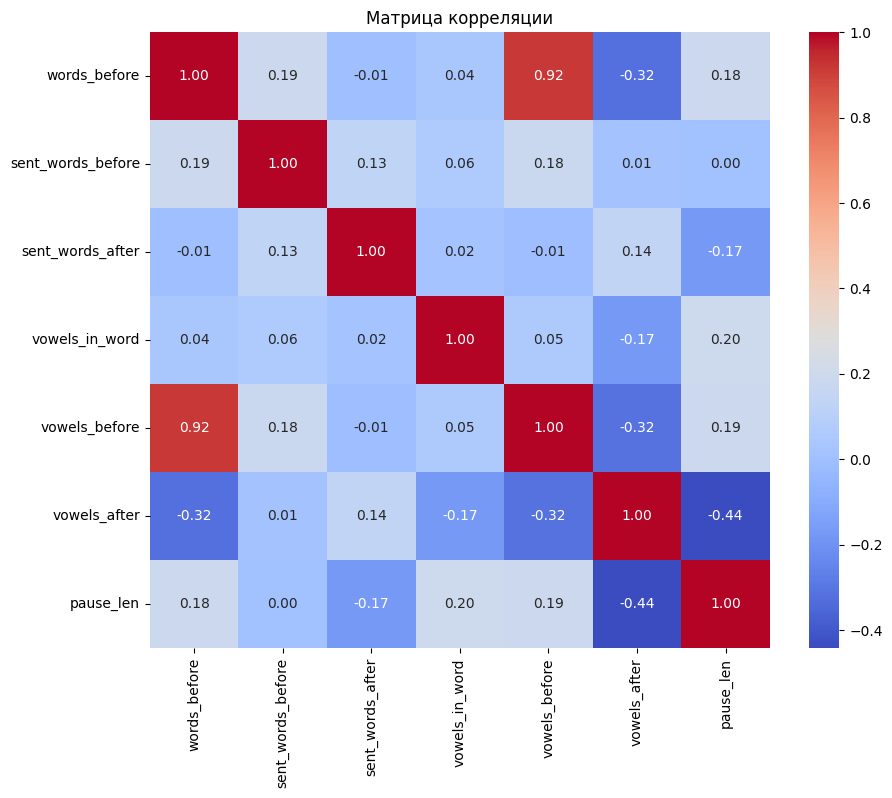

In [70]:
num_cols = ["words_before", 'sent_words_before', 'sent_words_after', 'vowels_in_word', 'vowels_before', 'vowels_after', 'pause_len']
numeric_df = df[num_cols]
corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляции")
plt.show()

In [43]:
# Заменить разные типы ядер на один тип
df['nucleus'] = df['nucleus'].replace({2: 1, 3: 1}).copy()

In [44]:
df.head()

,word,synt_num,word_length,part_of_speech,word_form,word_genesys,word_semantics1,word_semantics2,word_index,words_before,...,vowels_before,vowels_after,previous_word,next_word,capital_letter,nucleus,intonation,pause_len,pause_type,punctuation
0,ТЕМНЫЕ,1,6,3,39,0,0.0,0.0,1,0,...,0,3,None,АЛЛЕИ,1,0,11.0,0,0,1.0
1,АЛЛЕИ,1,5,2,9,5,0.0,0.0,2,1,...,3,0,ТЕМНЫЕ,None,1,1,11.0,1376,x-long,1.0
2,В,2,1,9,0,0,0.0,100.0,1,0,...,0,11,None,холодное,1,0,110.0,0,0,2.0
3,холодное,2,8,3,36,0,0.0,0.0,1,0,...,0,7,В,осеннее,0,0,110.0,0,0,2.0
4,осеннее,2,7,3,36,0,0.0,0.0,2,1,...,4,3,холодное,None,0,0,110.0,0,0,2.0


In [45]:
nan_cols = df.isna().any()
nan_cols

,0
word,False
synt_num,False
word_length,False
part_of_speech,False
word_form,False
word_genesys,False
word_semantics1,False
word_semantics2,False
word_index,False
words_before,False


In [46]:
len(df)

35284

# Обучение модели

In [47]:
# Метки из столбцов Nucleus и Pause_len
y_nucleus = df["nucleus"]
# Признаки категориальные, сами слова не учитываются, тип паузы тоже - он связан с длиной напрямую, индекс слова коррелирует с количеством слов до - поэтому тоже уберем
X = df.drop(columns=["nucleus", "pause_len", "word", "previous_word", "next_word", "pause_type", "word_index"])


## Предсказание ядра

In [48]:
# делим на train/test
len_train = int(len(X)*0.8)
len_test = len(X) - len_train
X_train = X[:len_train]
X_test = X[len_train:]
y_nucleus_train = y_nucleus[:len_train]
y_nucleus_test = y_nucleus[len_train:]
#X_train, X_test, y_nucleus_train, y_nucleus_test = train_test_split(X, y_nucleus, test_size=0.2, random_state=42)

In [49]:
print(len(X_train),
      len(X_test),
      len(y_nucleus_train),
      len(y_nucleus_test))

28227 7057 28227 7057


In [50]:
# Признаки будут числовыми и категориальными
numeric_cols = ["words_before", "words_after", 'sent_words_before', 'vowels_in_word', 'vowels_before', 'vowels_after']
categorical_cols = [c for c in X.columns if c not in numeric_cols]

In [51]:
# Катагориальные признаки преобразуются через OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)])

In [52]:
# Пайплайн для nucleus (классификация)
clf_nucleus = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42,
                                          criterion='gini',
                                          max_depth=13,
                                          min_samples_split=8,
                                          n_estimators=397,
                                          max_features=None,
                                          max_leaf_nodes=None,))
])


In [53]:
clf_nucleus.fit(X_train, y_nucleus_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['words_before',
                                                   'words_after',
                                                   'sent_words_before',
                                                   'vowels_in_word',
                                                   'vowels_before',
                                                   'vowels_after']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['synt_num', 'word_length',
                                                   'part_of_speech',
                                                   'word_form', 'word_genesys',
                                                   'word_semantics1',
                                                   'word_semantics2',
                                                   'sent_words_after',
                                                   'capital_letter',
                                                   'intonation',
                                                   'punctuation'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=13, max_features=None,
                                        min_samples_split=8, n_estimators=397,
                                        random_state=42))])

In [54]:
# оценка качества
print("Accuracy nucleus:", clf_nucleus.score(X_test, y_nucleus_test))

Accuracy nucleus: 0.9869632988522035


In [55]:
y_pred_nucleus = clf_nucleus.predict(X_test)


In [56]:
print(classification_report(y_nucleus_test, y_pred_nucleus))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5262
           1       0.98      0.97      0.97      1795

    accuracy                           0.99      7057
   macro avg       0.98      0.98      0.98      7057
weighted avg       0.99      0.99      0.99      7057



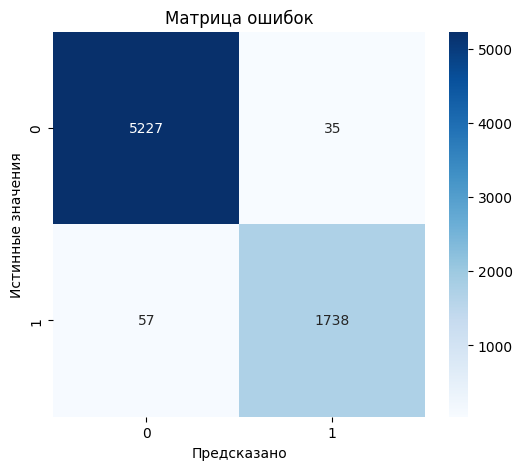

In [57]:
cm = confusion_matrix(y_nucleus_test, y_pred_nucleus)
labels = sorted(set(y_nucleus_test))  # метки классов

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Предсказано')
plt.ylabel('Истинные значения')
plt.title('Матрица ошибок')
plt.show()

## Предсказание длины паузы

In [58]:
df_pauses = df# df[df['pause_len']!=0]
y_pauses = df_pauses["pause_len"]

X_pauses = df_pauses.drop(columns=["nucleus", "pause_len", "word", "pause_type", "word_index", "words_after"])

In [59]:
numeric_cols = ["words_before", 'sent_words_before', 'sent_words_after', 'vowels_in_word', 'vowels_before', 'vowels_after']
categorical_cols = [c for c in X_pauses.columns if c not in numeric_cols]

# Катагориальные признаки преобразуются через OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)])

In [60]:
# пайплайн для pause_len (регрессия)
clf_pause = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", CatBoostRegressor(random_state=42, learning_rate=0.1, l2_leaf_reg=1, depth=8))
])


In [61]:
# делим на train/test
len_train_pause = int(len(X_pauses)*0.8)
X_train = X_pauses[:len_train_pause]
X_test = X_pauses[len_train_pause:]
y_pause_train = y_pauses[:len_train_pause]
y_pause_test = y_pauses[len_train_pause:]
print(len(X_train),
      len(X_test),
      len(y_pause_train),
      len(y_pause_test))

28227 7057 28227 7057


In [63]:
clf_pause.fit(X_train, y_pause_train)

0:	learn: 217.1890720	total: 182ms	remaining: 3m 1s
1:	learn: 200.1555579	total: 421ms	remaining: 3m 29s
2:	learn: 184.8548587	total: 658ms	remaining: 3m 38s
3:	learn: 171.9735689	total: 941ms	remaining: 3m 54s
4:	learn: 160.3517748	total: 1.23s	remaining: 4m 4s
5:	learn: 150.6100027	total: 1.5s	remaining: 4m 8s
6:	learn: 141.8213318	total: 1.86s	remaining: 4m 23s
7:	learn: 133.9806290	total: 2.19s	remaining: 4m 31s
8:	learn: 127.3170785	total: 2.48s	remaining: 4m 32s
9:	learn: 121.4640449	total: 2.89s	remaining: 4m 46s
10:	learn: 116.4582228	total: 3.51s	remaining: 5m 15s
11:	learn: 112.0747337	total: 3.9s	remaining: 5m 21s
12:	learn: 108.4647758	total: 4.24s	remaining: 5m 21s
13:	learn: 105.4809698	total: 4.54s	remaining: 5m 19s
14:	learn: 102.9963461	total: 4.84s	remaining: 5m 18s
15:	learn: 100.8314843	total: 5.13s	remaining: 5m 15s
16:	learn: 98.9920073	total: 5.75s	remaining: 5m 32s
17:	learn: 97.4563059	total: 6.3s	remaining: 5m 43s
18:	learn: 96.2146776	total: 6.6s	remaining: 5

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['words_before',
                                                   'sent_words_before',
                                                   'sent_words_after',
                                                   'vowels_in_word',
                                                   'vowels_before',
                                                   'vowels_after']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['synt_num', 'word_length',
                                                   'part_of_speech',
                                                   'word_form', 'word_genesys',
                                                   'word_semantics1',
                                                   'word_semantics2',
                                                   'previous_word', 'next_word',
                                                   'capital_letter',
                                                   'intonation',
                                                   'punctuation'])])),
                ('regressor',
                 <catboost.core.CatBoostRegressor object at 0x79ad6215d2b0>)])

In [64]:
y_pred_pause = clf_pause.predict(X_test)
# если предсказанная пауза < 100, ставим 0
y_pred_pause = [0 if val < 100 else val for val in y_pred_pause]

In [66]:

print("Pause_len R2:", r2_score(y_pause_test, y_pred_pause))

Pause_len R2: 0.8398968494134912


# Новые данные

In [67]:
fille_path = r'/content/bunin_i_a-text_2622.Result.xml'

new_data = parse_xml(fille_path)
new_df = get_features(new_data)

df['nucleus'] = df['nucleus'].replace({2: 1, 3: 1}).copy()

df['word_semantics1'] = df['word_semantics1'].fillna(0)
df['word_semantics2'] = df['word_semantics2'].fillna(0)
df['pause_len'] = df['pause_len'].fillna(0)

X_result = df.drop(columns=["nucleus", "pause_len", "word", "pause_type", "word_index"])

pause = clf_pause.predict(X_result)
nucleus = clf_nucleus.predict(X_result)


## Запись результатов в json

In [68]:
words_list = []

for i, (idx, row) in enumerate(X_result.iterrows()):
    word_info = {
        "content": df.loc[idx, "word"],               # само слово
        "phrasal_stress": bool(nucleus[i]),  # nucleus -> True/False
        "pause_len": int(pause[i]) if int(pause[i])>100 else -1            # пауза
    }
    words_list.append(word_info)

# формируем итоговый словарь
result_json = {"words": words_list}

# сохраняем в файл
with open("predictions.json", "w", encoding="utf-8") as f:
    json.dump(result_json, f, ensure_ascii=False, indent=2)